# Customer Segmentation Using Unsupervised Learning  
### End-to-End Machine Learning Capstone Project

**Author:** Your Name  
**Course:** Berkeley ML/AI Program

In this notebook, we build an end-to-end customer segmentation project using the provided dataset `customers.csv`.

We will walk through the full machine learning lifecycle:

1. Problem definition and scoping  
2. Data loading and initial inspection  
3. Exploratory data analysis (EDA)  
4. Data cleaning and preprocessing  
5. Feature engineering  
6. Model selection and clustering (K-Means)  
7. Hyperparameter tuning (choosing $k$)  
8. Model evaluation and visualization  
9. Cluster interpretation and business insights  
10. Future improvements and next steps  


## 1. Problem Definition and Scoping

Many businesses have rich customer data but lack a structured way to group customers into meaningful segments.  

**Business Problem:**  
We want to identify distinct customer groups based on demographic and behavioral attributes so that marketing and product teams can:

- Target specific segments with tailored campaigns  
- Personalize offers and recommendations  
- Allocate budget more efficiently  

**Machine Learning Framing:**  
- This is an **unsupervised learning** task.  
- Specifically, it is a **clustering** problem: we want to partition customers into $K$ groups such that customers in the same group are similar to each other and dissimilar to those in other groups.

**Success Criteria:**

- Clusters are **interpretable** and **well-separated**.  
- Segments correspond to **actionable business personas** (e.g., high-income high-spenders, young budget-conscious shoppers).  
- The pipeline is **reproducible** and easy to extend with additional features or data sources.


## 2. Setup and Imports

In this section, we import all the Python libraries we need for the analysis.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Plotting style
sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)


## 3. Data Loading and Initial Inspection

We start by loading the dataset `customers.csv` from the current working directory.

We will:

- Load the CSV into a pandas DataFrame  
- Inspect the first few rows  
- Check the data types and basic statistics  


In [2]:
# Load the dataset
df = pd.read_csv("customers.csv")

# Show first few rows
df.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [3]:
# Basic info about the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicatessen      440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [4]:
# Summary statistics for numeric and categorical columns
df.describe(include="all")


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


## 4. Exploratory Data Analysis (EDA)

The goal of EDA is to understand:

- What features are available and how they are distributed  
- Whether there are obvious outliers or anomalies  
- How the different variables relate to each other  

We will:

- Visualize distributions of key numeric variables  
- Explore categorical variables  
- Inspect relationships between potential clustering features  


### 4.1 Univariate Analysis for Numeric Features

We start by examining histograms and density plots for numeric features such as age, income, and any spending scores or purchase-related variables.


In [5]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols


['Channel',
 'Region',
 'Fresh',
 'Milk',
 'Grocery',
 'Frozen',
 'Detergents_Paper',
 'Delicatessen']

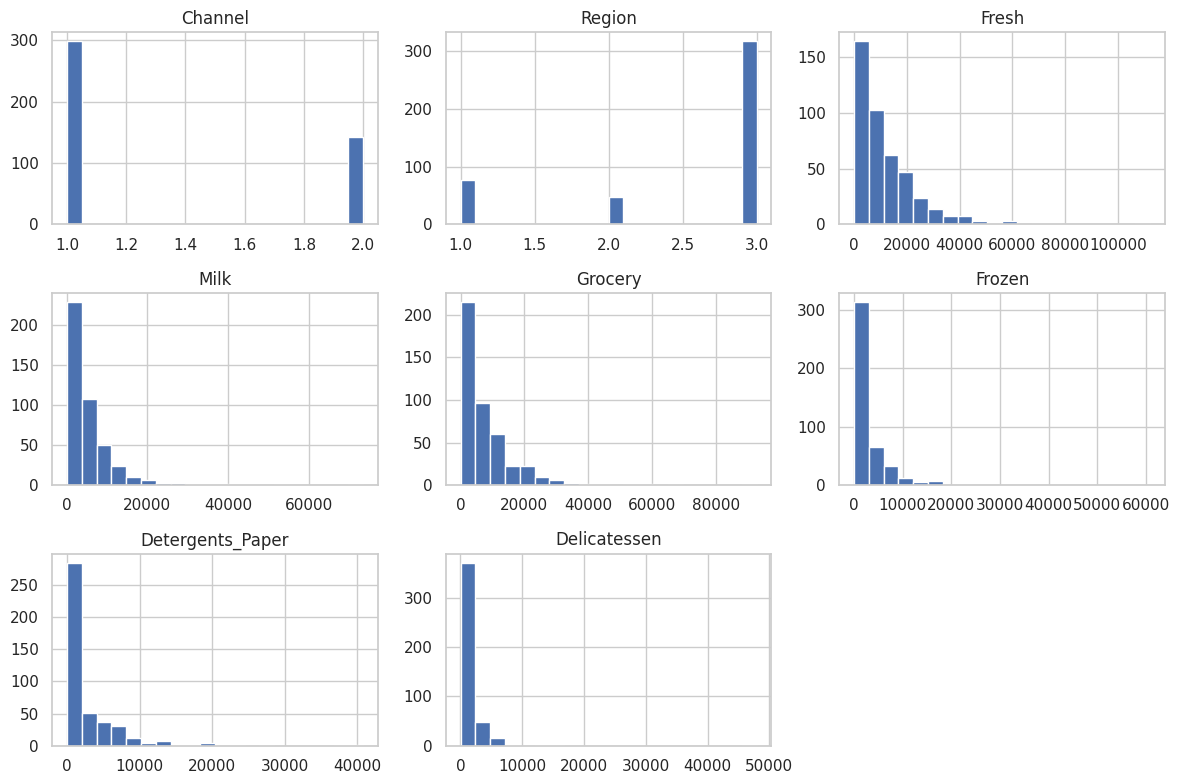

In [6]:
# Plot distributions for numeric columns
df[numeric_cols].hist(bins=20, figsize=(12, 8), layout=(len(numeric_cols)//3 + 1, 3))
plt.tight_layout()
plt.show()


### 4.2 Categorical Analysis

Next, we examine categorical variables such as gender or region, if present, to understand the composition of our customer base.


In [7]:
# Select categorical columns
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_cols


[]

In [8]:
# Count plots for categorical columns
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


### 4.3 Bivariate Analysis

To get a sense of how features interact, we can visualize relationships between pairs of numeric variables such as income vs. spending or age vs. spending.


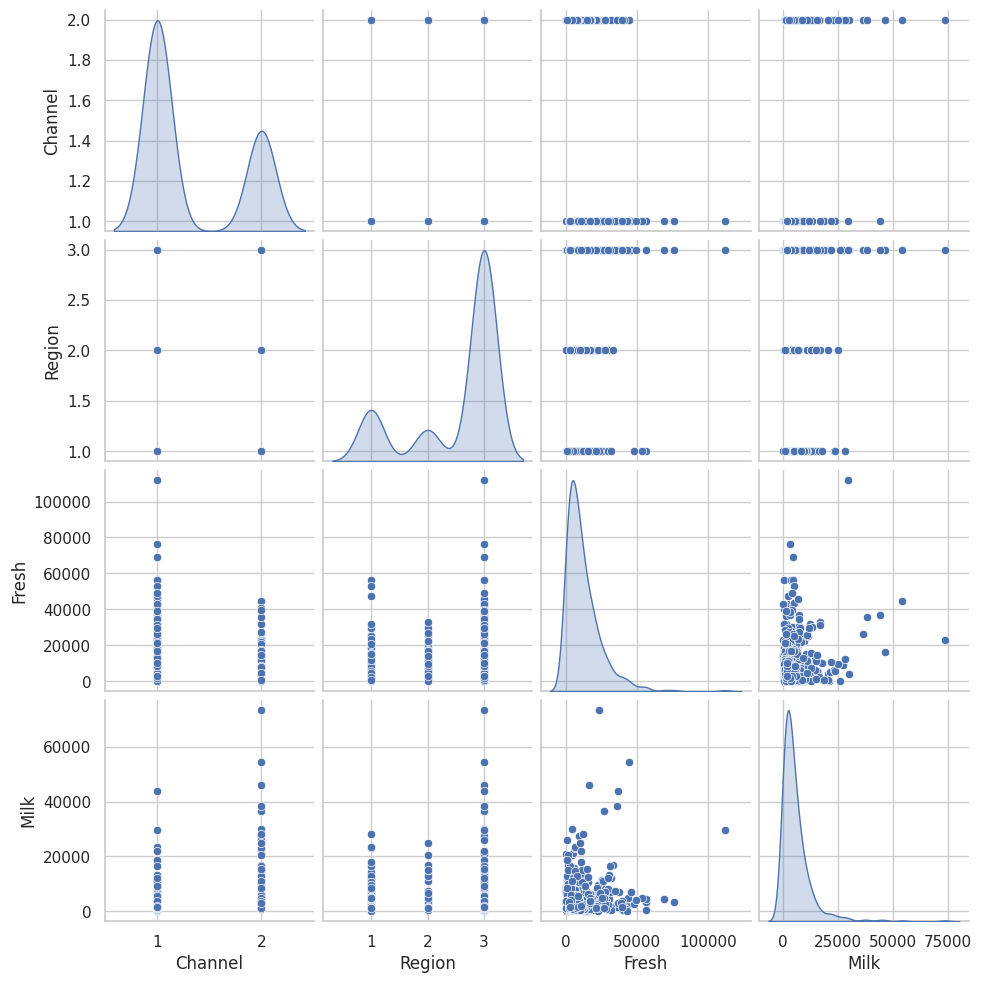

In [9]:
# Example: pairplot for selected numeric features (if there are many, limit to a subset)
subset_cols = numeric_cols[:4]  # adjust if needed
if len(subset_cols) > 1:
    sns.pairplot(df[subset_cols], diag_kind="kde")
    plt.show()


## 5. Data Cleaning and Preprocessing

Before clustering, we must ensure the data is clean and in a suitable format.

Steps:

- Check and handle missing values  
- Remove or transform any clearly problematic values  
- Drop identifiers or non-informative columns (e.g. customer IDs)  
- Encode categorical variables  
- Scale numeric features for clustering  


In [10]:
# Check for missing values
df.isna().sum()


,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicatessen,0


If there are missing values, we need to decide how to handle them:

- Drop rows with few missing values if the dataset is large  
- Impute with mean/median/mode for numeric variables  
- Impute with mode or introduce an 'Unknown' category for categorical variables  

For this demonstration, we will apply simple strategies.


In [11]:
# Simple missing value handling (customize as needed)
# Numeric: fill with median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical: fill with mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isna().sum()


,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicatessen,0


Next, we remove any columns that are identifiers or clearly not useful for clustering, such as raw IDs.


In [12]:
# Drop obvious identifier columns if present
id_cols = [col for col in df.columns if "id" in col.lower()]
id_cols


[]

In [13]:
df_clean = df.drop(columns=id_cols)
df_clean.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


### 5.1 Encoding Categorical Variables

Clustering algorithms like K-Means operate in numeric feature space.  
We convert categorical variables to numeric using one-hot encoding.


In [15]:
df_encoded = pd.get_dummies(df_clean, drop_first=True)
df_encoded.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


### 5.2 Feature Scaling

Many clustering algorithms, including K-Means, are distance-based and sensitive to feature scale.  

We standardize all features to have zero mean and unit variance:

$$
z = \frac{x - \mu}{\sigma}
$$


In [16]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df_encoded)

scaled_df = pd.DataFrame(scaled, columns=df_encoded.columns)
scaled_df.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,1.448652,0.590668,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,1.448652,0.590668,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,1.448652,0.590668,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,-0.690297,0.590668,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,1.448652,0.590668,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347


## 6. Model Selection: Clustering with K-Means

We will use **K-Means** clustering as our primary algorithm.  

K-Means aims to partition the dataset into $K$ clusters by minimizing the within-cluster sum of squared distances:

$$
\min_{C_1,\dots,C_K} \sum_{k=1}^K \sum_{x_i \in C_k} \lVert x_i - \mu_k \rVert^2
$$

where $\mu_k$ is the centroid of cluster $C_k$.


### 6.1 Choosing the Number of Clusters (Elbow Method)

We will compute K-Means models for different values of $K$ and plot the inertia (within-cluster sum of squares) to identify an "elbow" point.


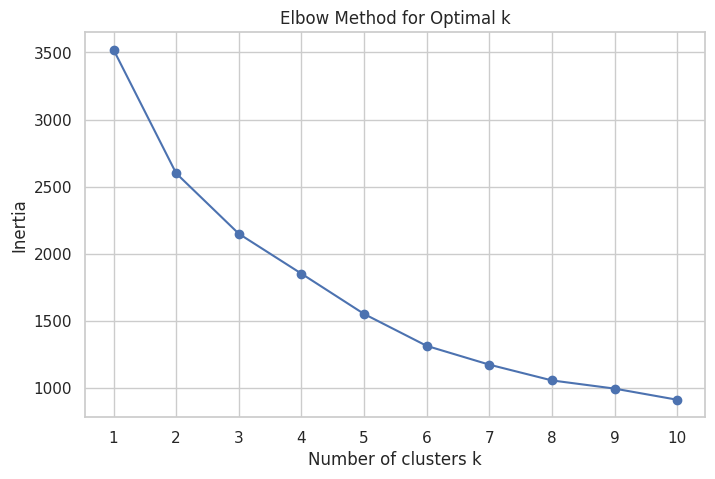

In [17]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_df)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker="o")
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.xticks(K_range)
plt.show()


We look for the value of $k$ where the decrease in inertia begins to level off (the "elbow").

This suggests a good trade-off between cluster compactness and model complexity.

We could select $k = 7$ or $k=8$.



### 6.2 Evaluating Cluster Quality with Silhouette Score

To further support our choice of $k$, we use the **silhouette score**, which measures how similar a sample is to its own cluster vs. other clusters.

The silhouette score $s(i)$ for sample $i$ is:

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

where:

- $a(i)$ is the average distance to all other points in the same cluster  
- $b(i)$ is the minimum average distance to points in any other cluster  

$s(i)$ ranges from $-1$ (poor) to $1$ (dense, well-separated cluster).


In [18]:
silhouette_scores = {}

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_df)
    score = silhouette_score(scaled_df, labels)
    silhouette_scores[k] = score

silhouette_scores


{2: np.float64(0.3733740311185568),
 3: np.float64(0.3567685389017652),
 4: np.float64(0.34819485747460033),
 5: np.float64(0.35292393966569646),
 6: np.float64(0.3525837344718669),
 7: np.float64(0.3638318723917674),
 8: np.float64(0.37426467849449924),
 9: np.float64(0.30805486690009953)}

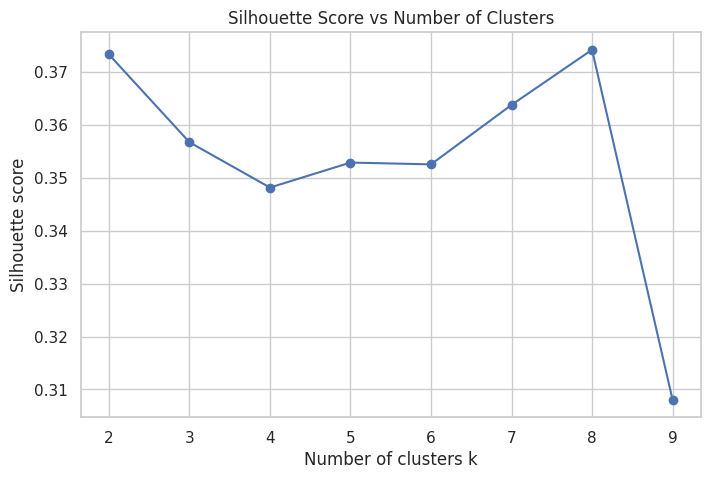

In [19]:
plt.figure(figsize=(8,5))
ks = list(silhouette_scores.keys())
scores = list(silhouette_scores.values())
plt.plot(ks, scores, marker="o")
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.xticks(ks)
plt.show()


Based on the elbow plot and the silhouette scores, we choose a value of $k$ that balances cluster compactness and separation.  

For this notebook, we will assume $k = 8$ is a good choice (you may adjust based on your plots).


## 7. Training the Final K-Means Model

We now train a K-Means model with our chosen number of clusters (e.g. $k = 8$) on the scaled feature matrix.


In [22]:
optimal_k = 8  # adjust if needed based on previous analysis

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_df)

df_encoded["Cluster"] = cluster_labels
df_encoded["Cluster"].value_counts().sort_index()


,count
Cluster,
0,201
1,92
2,37
3,61
4,2
5,5
6,1
7,41


In [23]:
optimal_k = 5  # adjust if needed based on previous analysis

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_df)

df_encoded["Cluster"] = cluster_labels
df_encoded["Cluster"].value_counts().sort_index()

,count
Cluster,
0,6
1,126
2,91
3,207
4,10


Each customer is now assigned a cluster label from $0$ to $k-1$.  
Next, we will visualize and interpret these clusters.


## 8. Cluster Visualization

To visualize clusters in a 2D space, we can either:

- Use two meaningful features directly (e.g. income vs. spending), or  
- Use dimensionality reduction such as **PCA** to project high-dimensional data into 2D.


In [24]:
# If we have obvious "business" axes like income and spending, try to detect them by name
cols_lower = [c.lower() for c in df_clean.columns]
income_candidates = [c for c in df_clean.columns if "income" in c.lower()]
spend_candidates = [c for c in df_clean.columns if "spend" in c.lower() or "score" in c.lower()]

income_col = income_candidates[0] if income_candidates else numeric_cols[0]
spend_col = spend_candidates[0] if spend_candidates else (numeric_cols[1] if len(numeric_cols) > 1 else numeric_cols[0])

income_col, spend_col


('Channel', 'Region')

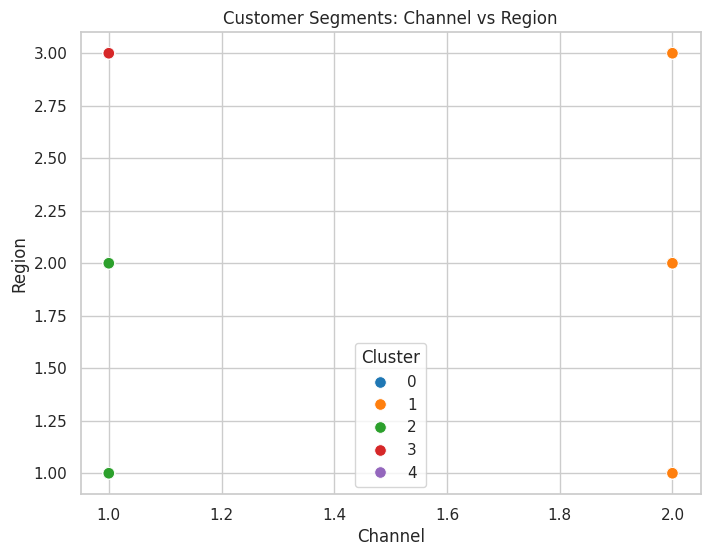

In [25]:
# Scatterplot using chosen income and spending-like columns
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df_clean[income_col],
    y=df_clean[spend_col],
    hue=df_encoded["Cluster"],
    palette="tab10",
    s=70
)
plt.title(f"Customer Segments: {income_col} vs {spend_col}")
plt.show()


The plot above shows how clusters differ along two key business features (e.g., income and spending score).  

Next, we use Principal Component Analysis (PCA) to view clusters in a compressed 2D space capturing most of the variance.


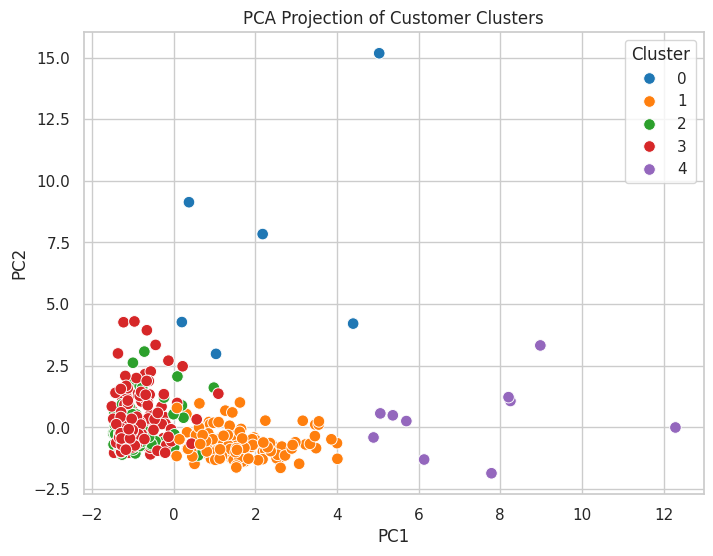

In [26]:
pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(scaled_df)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=components[:,0],
    y=components[:,1],
    hue=df_encoded["Cluster"],
    palette="tab10",
    s=70
)
plt.title("PCA Projection of Customer Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


## 9. Cluster Profiling and Interpretation

To understand each segment, we compute the average feature values per cluster and interpret them as personas.


In [27]:
cluster_profile = df_encoded.groupby("Cluster").mean()
cluster_profile


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
Cluster,,,,,,,,
0,1.166667,2.833333,44940.666667,22179.166667,17187.000000,21831.166667,2758.000000,17908.000000
1,2.000000,2.674603,8130.031746,8874.071429,14139.150794,1339.476190,6104.936508,1542.706349
2,1.054945,1.307692,12183.945055,3254.714286,4130.923077,3458.252747,860.263736,1149.934066
3,1.000000,3.000000,13129.057971,3168.526570,3635.864734,3413.729469,749.038647,1135.468599
4,2.000000,2.500000,15964.900000,34708.500000,48536.900000,3054.600000,24875.200000,2942.800000


We can also merge the original (unencoded) data with the cluster labels for easier interpretation.


In [28]:
df_clusters = df_clean.copy()
df_clusters["Cluster"] = cluster_labels
df_clusters.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen,Cluster
0,2,3,12669,9656,7561,214,2674,1338,1
1,2,3,7057,9810,9568,1762,3293,1776,1
2,2,3,6353,8808,7684,2405,3516,7844,1
3,1,3,13265,1196,4221,6404,507,1788,3
4,2,3,22615,5410,7198,3915,1777,5185,1


In [29]:
# Summary statistics by cluster for original features
df_clusters.groupby("Cluster").agg(["mean", "median", "min", "max"])


Channel                   Region                        Fresh  \
             mean median min max      mean median min max          mean   
Cluster                                                                   
0        1.166667    1.0   1   2  2.833333    3.0   2   3  44940.666667   
1        2.000000    2.0   2   2  2.674603    3.0   1   3   8130.031746   
2        1.054945    1.0   1   2  1.307692    1.0   1   2  12183.945055   
3        1.000000    1.0   1   1  3.000000    3.0   3   3  13129.057971   
4        2.000000    2.0   2   2  2.500000    3.0   1   3  15964.900000   

                  ... Frozen        Detergents_Paper                         \
          median  ...    min    max             mean   median    min    max   
Cluster           ...                                                         
0        34782.0  ...   5154  60869      2758.000000   2876.0    239   4948   
1         5474.0  ...     33   8132      6104.936508   5151.5    523  17120   
2         9193.0  ...     91  18711       860.263736    402.0      5   5828   
3         9561.0  ...     25  35009       749.038647    370.0      3   6907   
4        10658.5  ...     36   7782     24875.200000  22120.5  17740  40827   

         Delicatessen                        
                 mean   median   min    max  
Cluster                                      
0        17908.000000  14411.5  5609  47943  
1         1542.706349   1271.5     3   7844  
2         1149.934066    834.0     7   6854  
3         1135.468599    790.0     3   5864  
4         2942.800000   2443.5   903   6465  

[5 rows x 32 columns]

### 9.1 Example Interpretation (Customize Based on Your Data)

Use the cluster summary statistics to describe each cluster in business language. For example:

- **Cluster 0:**  
  - Higher-than-average income and spending  
  - Likely "Premium Shoppers" who respond well to luxury offers  

- **Cluster 1:**  
  - Lower income and low spending  
  - Price-sensitive customers, good candidates for discounts and coupons  

- **Cluster 2:**  
  - High income but moderate or low spending  
  - Untapped potential; consider loyalty programs or personalized outreach  

- **Cluster 3:**  
  - Younger customers with high spending scores  
  - Trend-driven segment, suitable for social media and influencer campaigns  

- **Cluster 4:**  
  - Middle income and steady spending  
  - Core customer base, maintain engagement with regular promotions  

You should refine these descriptions using the actual values from your dataset.


## 10. Future Improvements and Next Steps

Possible extensions to this project:

- Incorporate **transaction history** (e.g., total spend, number of visits, recency)  
- Add **geographic** or **channel** information (online vs in-store)  
- Experiment with other clustering algorithms:
  - Gaussian Mixture Models (GMM)
  - Hierarchical clustering
  - DBSCAN for arbitrary-shaped clusters  
- Use **soft clustering** to assign probabilities of belonging to each segment  
- Build **segment-specific recommendation systems** or marketing strategies  

In a production setting, you would also:

- Save the scaler and model artifacts (e.g., using `joblib`)  
- Build an API endpoint to assign clusters to new customers  
- Monitor data drift and re-train the model periodically  


## 11. Conclusion

In this notebook, we completed an end-to-end customer segmentation project using unsupervised learning:

- Defined the segmentation problem in a business context  
- Loaded and explored the `customers.csv` dataset  
- Cleaned and preprocessed the data (handling missing values, encoding, scaling)  
- Used K-Means clustering and silhouette analysis to choose the number of clusters  
- Visualized and interpreted the resulting clusters  
- Proposed actionable business personas and future improvements  

This workflow can serve as a template for many segmentation problems across different industries.
